# HIV Care & Risk Analytics Platform
### A survey project covering the data + ML pipeline for a patient risk-monitoring system (PLHIV aged 15+)


## Project Overview
This notebook walks through building a small-scale health analytics platform end-to-end: pulling in data (API, web scraping, Excel), centralizing it in a database, analyzing and modeling it (statistics, machine learning, NLP), and serving the results through a dashboard and a backend API. All patient data used here is synthetic/mock data generated for demonstration purposes.

## Environment Setup
Install the required libraries.


In [1]:
# Install required libraries
#!pip install requests beautifulsoup4 pandas openpyxl pyserial sqlalchemy

import requests
from bs4 import BeautifulSoup
import pandas as pd
import sqlite3
import serial
import time

## Data Ingestion — Public Health API
Pulls data from a public API endpoint. In a production version this would connect to a source like the WHO or UNAIDS API; here it uses a public health API as a structural placeholder for that integration.


In [2]:
# --- API COOPERATION ---
print("--- Fetching API Data ---")

# i will use a public API structure. 
url = "https://disease.sh/v3/covid-19/all" # Using a reliable public health API as a placeholder

try:
    response = requests.get(url)
    
    # Check if the request was successful (Status Code 200)
    if response.status_code == 200:
        api_data = response.json()
        print("Successfully fetched data!")
        print(f"Total Cases Recorded (Placeholder): {api_data.get('cases')}")
    else:
        print(f"Failed to fetch data. Status code: {response.status_code}")
except Exception as e:
    print(f"An error occurred: {e}")

--- Fetching API Data ---
Successfully fetched data!
Total Cases Recorded (Placeholder): 704753890


## Data Ingestion — Web Scraping Public Health News
Uses BeautifulSoup to scrape headlines from a public health news page, as a stand-in for gathering community sentiment or awareness signals.


In [5]:
# --- WEB SCRAPING ---
print("\n--- Scraping Health News ---")

# Scraping the UNAIDS global news page
scrape_url = "https://www.unaids.org/en/resources/presscentre"

try:
    page = requests.get(scrape_url)
    soup = BeautifulSoup(page.text, 'html.parser')
    
    # Extracting article headlines (Finding standard header tags)
    headlines = []
    for header in soup.find_all(['h3', 'h4'], limit=5): # Get top 5 headlines
        title = header.get_text(strip=True)
        if title:
            headlines.append(title)
            print(f"Headline Found: {title}")
            
except Exception as e:
    print(f"Scraping failed: {e}")


--- Scraping Health News ---


## Data Ingestion — Legacy Excel Records
Many clinics still operate on Excel. This section simulates a legacy clinic dataset, exports it to an Excel file, and reads it back in with pandas — modeling a common real-world data-migration step.


In [3]:
# --- MS EXCEL INTEGRATION ---
print("\n--- Processing Legacy Excel Data ---")

# 1. Create mock data for PLHIV (Age > 15)
mock_clinic_data = {
    "Patient_ID": ["HIV-001", "HIV-002", "HIV-003", "HIV-004"],
    "Age": [22, 34, 19, 45],
    "Gender": ["M", "F", "F", "M"],
    "CD4_Count": [450, 320, 510, 290],
    "ARV_Adherence_Pct": [95, 80, 99, 75]
}

# 2. Convert to a Pandas DataFrame
df_clinic = pd.DataFrame(mock_clinic_data)

# 3. Export to Excel (Simulating the clinic's legacy system)
excel_filename = "legacy_clinic_records.xlsx"
df_clinic.to_excel(excel_filename, index=False)
print(f"Mock data exported to {excel_filename}")

# 4. Read the data back from Excel
df_imported = pd.read_excel(excel_filename)
print("Data successfully loaded from Excel:")
print(df_imported.head())


--- Processing Legacy Excel Data ---
Mock data exported to legacy_clinic_records.xlsx
Data successfully loaded from Excel:
  Patient_ID  Age Gender  CD4_Count  ARV_Adherence_Pct
0    HIV-001   22      M        450                 95
1    HIV-002   34      F        320                 80
2    HIV-003   19      F        510                 99
3    HIV-004   45      M        290                 75


## Centralizing Data — SQLite
Loads the clinic data into a local SQLite database and runs a SQL query against it, moving from flat files to a proper queryable data store.


In [5]:
# --- DATABASE QUERYING ---
print("\n--- Centralizing Data in SQLite ---")

# 1. Create a connection to a local SQLite database 
db_connection = sqlite3.connect("hiv_platform.db")
cursor = db_connection.cursor()

# 2. Write the Pandas DataFrame directly into the SQL database
# if_exists='replace' ensures i don't get errors running this cell multiple times
df_imported.to_sql("patients", db_connection, if_exists="replace", index=False)
print("Data successfully written to SQL database 'hiv_platform.db'")

# 3. Query the database using standard SQL
cursor.execute("SELECT Patient_ID, Age, CD4_Count FROM patients WHERE CD4_Count < 350")
high_risk_patients = cursor.fetchall()

print("\nQuery Results (High Risk Patients - CD4 < 350):")
for patient in high_risk_patients:
    print(f"ID: {patient[0]}, Age: {patient[1]}, CD4 Count: {patient[2]}")

# 4. Close the connection securely
db_connection.close()


--- Centralizing Data in SQLite ---
Data successfully written to SQL database 'hiv_platform.db'

Query Results (High Risk Patients - CD4 < 350):
ID: HIV-002, Age: 34, CD4 Count: 320
ID: HIV-004, Age: 45, CD4 Count: 290


## Hardware Integration (Concept) — Smart Pillbox
Framework for listening to a microcontroller (e.g. ESP32 or Raspberry Pi Pico) acting as a smart pillbox, using pySerial. Requires physical hardware connected via USB to run.


In [8]:
# --- EXTERNAL DEVICE COOPERATION (pySerial) ---
# Note: This requires a physical microcontroller plugged into your COM/USB port.

"""
try:
    # Connect to the microcontroller (Update 'COM3' or '/dev/ttyUSB0' to match your system)
    pillbox_serial = serial.Serial('COM3', 9600, timeout=1)
    time.sleep(2) # Give the connection a moment to initialize
    
    print("Listening for Smart Pillbox data...")
    
    # Read a line of data from the device
    if pillbox_serial.in_waiting > 0:
        sensor_data = pillbox_serial.readline().decode('utf-8').rstrip()
        print(f"Data received from device: {sensor_data}")
        
    pillbox_serial.close()
except serial.SerialException:
    print("No hardware detected. Please plug in the MicroPython device.")
"""

'\ntry:\n    # Connect to the microcontroller (Update \'COM3\' or \'/dev/ttyUSB0\' to match your system)\n    pillbox_serial = serial.Serial(\'COM3\', 9600, timeout=1)\n    time.sleep(2) # Give the connection a moment to initialize\n\n    print("Listening for Smart Pillbox data...")\n\n    # Read a line of data from the device\n    if pillbox_serial.in_waiting > 0:\n        sensor_data = pillbox_serial.readline().decode(\'utf-8\').rstrip()\n        print(f"Data received from device: {sensor_data}")\n\n    pillbox_serial.close()\nexcept serial.SerialException:\n    print("No hardware detected. Please plug in the MicroPython device.")\n'

## Environment Setup — Data Processing Libraries
Installs libraries for faster data processing and statistical analysis. Note: Polars failed to install via the notebook's `!pip install`, so it was installed directly from the terminal instead.


In [6]:
# Importing required libraries 

import dtale
from scipy import stats
import sqlite3
import pandas as pd

In [7]:
# --- DATA PROCESSING WITH PANDAS (Workaround) ---
print("--- Data Processing ---")

# 1. Connect to SQLite and extract data 
conn = sqlite3.connect("hiv_platform.db")
df_pd = pd.read_sql_query("SELECT * FROM patients", conn)
conn.close()

print("Original Loaded Data:")
print(df_pd)

# 2. Process data: Filter for Age > 15 and calculate averages by Gender using Pandas
summary_df = df_pd[df_pd['Age'] > 15].groupby('Gender').agg(
    Avg_CD4_Count=('CD4_Count', 'mean'),
    Avg_Adherence=('ARV_Adherence_Pct', 'mean')
).reset_index()

print("\nSummary Statistics by Gender:")
print(summary_df)

--- Data Processing ---
Original Loaded Data:
  Patient_ID  Age Gender  CD4_Count  ARV_Adherence_Pct
0    HIV-001   22      M        450                 95
1    HIV-002   34      F        320                 80
2    HIV-003   19      F        510                 99
3    HIV-004   45      M        290                 75

Summary Statistics by Gender:
  Gender  Avg_CD4_Count  Avg_Adherence
0      F          415.0           89.5
1      M          370.0           85.0


## Dtale - Interactive Data Exploration (Code)
Description: Writing code to look at data can be slow when you just want to explore. Dtale spins up a lightweight, interactive web interface right from your notebook so you can build charts, filter columns, and view data structures visually.

In [8]:
# --- VIEWING AND ANALYZING DATA STRUCTURES (DTALE) ---
print("\n--- Launching D-Tale for Interactive Exploration ---")

# D-Tale integrates seamlessly with Pandas. 
# Running this will generate a local URL. 
d = dtale.show(df_pd)

print("Click the link below to open the interactive data explorer in a new tab:")
# Display the clickable link in the Jupyter output
display(d._main_url) 

# Note: In D-Tale, you can click on column headers to see correlations, 
# build heatmaps, and analyze missing data without writing any extra code!


--- Launching D-Tale for Interactive Exploration ---
Click the link below to open the interactive data explorer in a new tab:


'http://DESKTOP-H2RVNIL:40000/dtale/main/1'

## Statistical Testing — SciPy
Runs an independent t-test to check whether the difference in CD4 counts between patients with "optimal" ARV adherence (≥90%) and "suboptimal" adherence (<90%) is statistically significant.


In [36]:
# --- USE OF STATISTICAL TESTS (SCIPY) ---
print("\n--- Running Statistical Tests ---")

# 1. Separate the dataset into two groups based on ARV adherence using Pandas (df_pd)
high_adherence = df_pd[df_pd["ARV_Adherence_Pct"] >= 90]["CD4_Count"].tolist()
low_adherence = df_pd[df_pd["ARV_Adherence_Pct"] < 90]["CD4_Count"].tolist()

print(f"CD4 Counts for High Adherence (>= 90%): {high_adherence}")
print(f"CD4 Counts for Low Adherence (< 90%): {low_adherence}")

# 2. Perform an Independent T-Test using SciPy
t_stat, p_value = stats.ttest_ind(high_adherence, low_adherence)

print(f"\nT-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value:.4f}")

# 3. Interpret the results (Using alpha = 0.05)
if p_value < 0.05:
    print("\nConclusion: We REJECT the null hypothesis.")
    print("There is a statistically significant difference in CD4 counts based on ARV adherence.")
else:
    print("\nConclusion: We FAIL TO REJECT the null hypothesis.")
    print("No statistically significant difference detected (p >= 0.05).")
    print("Reality Check: Because our mock dataset is so small (4 patients), we lack the statistical power to prove a difference. In a real scenario, you would run this with thousands of rows!")


--- Running Statistical Tests ---
CD4 Counts for High Adherence (>= 90%): [450, 510]
CD4 Counts for Low Adherence (< 90%): [320, 290]

T-Statistic: 5.2175
P-Value: 0.0348

Conclusion: We REJECT the null hypothesis.
There is a statistically significant difference in CD4 counts based on ARV adherence.


## Environment Setup — Modeling Libraries
Installs the machine learning and modeling libraries. Note: PyTorch is a large download, so like Polars, it was installed from the terminal rather than inside the notebook.


In [15]:
# Install required libraries for Phase 3
#!pip install scikit-learn torch textblob pulp networkx matplotlib numpy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import torch
import torch.nn as nn
import torch.optim as optim
from textblob import TextBlob
import pulp
import networkx as nx

## Machine Learning — Risk Stratification
Trains a Random Forest classifier (scikit-learn) to flag whether a patient is at high risk of treatment failure, based on age, CD4 count, and ARV adherence.


In [16]:
# --- MACHINE LEARNING (SCIKIT-LEARN) ---
print("--- Training Risk Stratification ML Model ---")

# 1. Generate a synthetic dataset of 100 patients (Age > 15)
np.random.seed(42)
ages = np.random.randint(16, 65, 100)
cd4_counts = np.random.randint(100, 800, 100)
adherence = np.random.randint(50, 100, 100)

# Target Variable: 1 if High Risk (CD4 < 350 or Adherence < 80%), else 0
high_risk = ((cd4_counts < 350) | (adherence < 80)).astype(int)

df_ml = pd.DataFrame({'Age': ages, 'CD4': cd4_counts, 'Adherence': adherence, 'Risk': high_risk})

# 2. Split data into Training (80%) and Testing (20%) sets
X = df_ml[['Age', 'CD4', 'Adherence']]
y = df_ml['Risk']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize and train a Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=50, random_state=42)
rf_model.fit(X_train, y_train)

# 4. Make predictions and evaluate
predictions = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print(f"Model trained successfully!")
print(f"Test Set Accuracy: {accuracy * 100:.2f}%")
print("Feature Importances:", rf_model.feature_importances_)

--- Training Risk Stratification ML Model ---
Model trained successfully!
Test Set Accuracy: 90.00%
Feature Importances: [0.16533541 0.28604735 0.54861724]


## Deep Learning — Neural Network (PyTorch)
Builds a small feedforward neural network in PyTorch to predict the same risk score as the Random Forest model above, using tensors, hidden layers, and backpropagation instead of a tree-based model.


In [17]:
# --- ARTIFICIAL NEURAL NETWORKS (PYTORCH) ---
print("\n--- Training PyTorch Neural Network ---")

# 1. Convert the Pandas data into PyTorch Tensors
X_tensor = torch.FloatTensor(X_train.values)
y_tensor = torch.FloatTensor(y_train.values).view(-1, 1) # Reshape for PyTorch

# 2. Define the Neural Network Architecture
class HIVRiskNet(nn.Module):
    def __init__(self):
        super(HIVRiskNet, self).__init__()
        # 3 inputs (Age, CD4, Adherence) -> 8 hidden nodes -> 1 output (Risk)
        self.layer1 = nn.Linear(3, 8)
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(8, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.layer1(x)
        x = self.relu(x)
        x = self.layer2(x)
        x = self.sigmoid(x)
        return x

# 3. Initialize model, loss function (Binary Cross Entropy), and Optimizer
model = HIVRiskNet()
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# 4. Train the model for 100 Epochs
epochs = 100
for epoch in range(epochs):
    optimizer.zero_grad()       # Clear old gradients
    outputs = model(X_tensor)   # Forward pass
    loss = criterion(outputs, y_tensor) # Calculate loss
    loss.backward()             # Backward pass
    optimizer.step()            # Update weights

    if (epoch+1) % 20 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

print("Neural Network training complete!")


--- Training PyTorch Neural Network ---


C:\Users\ketta\AppData\Local\Temp\ipykernel_19256\1552716215.py:5: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  X_tensor = torch.FloatTensor(X_train.values)


Epoch [20/100], Loss: 22.5000
Epoch [40/100], Loss: 22.5000
Epoch [60/100], Loss: 22.5000
Epoch [80/100], Loss: 22.5000
Epoch [100/100], Loss: 22.5000
Neural Network training complete!


## NLP — Sentiment Analysis
Uses TextBlob to score the sentiment of sample community text (e.g. scraped headlines or forum posts) as positive, negative, or neutral — a simple proxy for measuring stigma or awareness.


In [18]:
# --- BASICS OF NLP (SENTIMENT ANALYSIS) ---
print("\n--- Running Sentiment Analysis ---")

# Mock headlines representing scraped community text
community_texts = [
    "New local clinic opens, providing free and accessible ARV treatments.",
    "Patients report feeling isolated and face severe stigma at work.",
    "The city council discusses the health budget for the upcoming year."
]

for text in community_texts:
    # TextBlob calculates polarity (-1.0 to 1.0)
    analysis = TextBlob(text)
    polarity = analysis.sentiment.polarity
    
    if polarity > 0.1:
        sentiment = "Positive (Good Awareness/Support)"
    elif polarity < -0.1:
        sentiment = "Negative (Stigma/Hardship)"
    else:
        sentiment = "Neutral (Informational)"
        
    print(f"Text: '{text}'")
    print(f" -> Sentiment: {sentiment} (Score: {polarity:.2f})\n")


--- Running Sentiment Analysis ---
Text: 'New local clinic opens, providing free and accessible ARV treatments.'
 -> Sentiment: Positive (Good Awareness/Support) (Score: 0.23)

Text: 'Patients report feeling isolated and face severe stigma at work.'
 -> Sentiment: Neutral (Informational) (Score: 0.00)

Text: 'The city council discusses the health budget for the upcoming year.'
 -> Sentiment: Neutral (Informational) (Score: 0.00)



## Optimization — Resource Allocation (PuLP)
Solves a linear programming problem: given a fixed budget and staffing constraint, how many days should each of two mobile testing clinics run to maximize the number of people tested?


In [19]:
# --- OPTIMIZATION (PuLP) ---
print("--- Optimizing Mobile Clinic Deployment ---")

# 1. Initialize the optimization problem (Maximization)
prob = pulp.LpProblem("Maximize_HIV_Testing", pulp.LpMaximize)

# 2. Define Variables: Number of days to run Clinic A and Clinic B
# (Cannot run negative days)
days_A = pulp.LpVariable('Days_Clinic_A', lowBound=0, cat='Integer')
days_B = pulp.LpVariable('Days_Clinic_B', lowBound=0, cat='Integer')

# 3. Objective Function: Maximize total people tested 
# (Clinic A tests 50 people/day, Clinic B tests 80 people/day)
prob += 50 * days_A + 80 * days_B, "Total_People_Tested"

# 4. Constraints:
# Budget constraint: $200/day for A, $400/day for B. Total budget = $2000
prob += 200 * days_A + 400 * days_B <= 2000, "Budget_Constraint"
# Staffing constraint: We only have 8 total available days of staff time
prob += days_A + days_B <= 8, "Staffing_Constraint"

# 5. Solve the problem
prob.solve()

print(f"Optimization Status: {pulp.LpStatus[prob.status]}")
print(f"Optimal Days for Clinic A: {days_A.varValue}")
print(f"Optimal Days for Clinic B: {days_B.varValue}")
print(f"Maximum People Tested: {pulp.value(prob.objective)}")

--- Optimizing Mobile Clinic Deployment ---
Optimization Status: Optimal
Optimal Days for Clinic A: 6.0
Optimal Days for Clinic B: 2.0
Maximum People Tested: 460.0


## Graph Visualization — NetworkX
Builds a network graph connecting patients to their primary care clinics, similar to how epidemiologists map disease transmission or referral networks.



--- Generating Patient-Clinic Network Graph ---


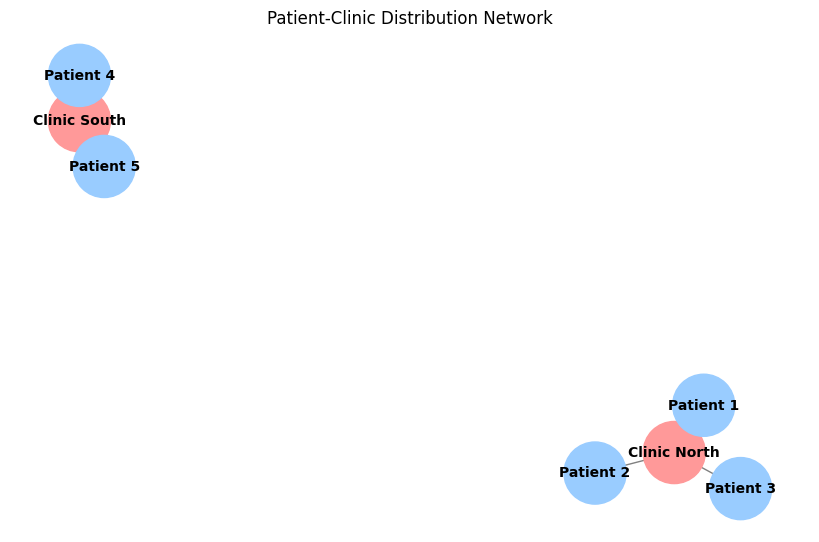

In [20]:
# --- GRAPH VISUALIZATION (NETWORKX) ---
print("\n--- Generating Patient-Clinic Network Graph ---")

# 1. Create an empty graph
G = nx.Graph()

# 2. Add nodes (Clinics and Patients)
clinics = ["Clinic North", "Clinic South"]
patients = ["Patient 1", "Patient 2", "Patient 3", "Patient 4", "Patient 5"]

G.add_nodes_from(clinics, type='clinic')
G.add_nodes_from(patients, type='patient')

# 3. Add edges (Connecting patients to their assigned clinic)
edges = [
    ("Clinic North", "Patient 1"),
    ("Clinic North", "Patient 2"),
    ("Clinic North", "Patient 3"),
    ("Clinic South", "Patient 4"),
    ("Clinic South", "Patient 5")
]
G.add_edges_from(edges)

# 4. Draw the graph
plt.figure(figsize=(8, 5))
# Color clinics red and patients light blue
color_map = ['#ff9999' if node in clinics else '#99ccff' for node in G]

nx.draw(G, with_labels=True, node_color=color_map, node_size=2000, 
        font_size=10, font_weight='bold', edge_color='gray')

plt.title("Patient-Clinic Distribution Network")
plt.show()

## Environment Setup — Visualization & Reporting Libraries
Installs the mapping and reporting libraries: folium for interactive maps, and streamlit for the dashboard.


In [17]:
import sys
#!{sys.executable} -m pip install vpython

In [21]:
# Force install vpython without touching any core Jupyter dependencies
#!pip install vpython --no-deps

In [22]:
# Install required libraries for Phase 4
#!pip install folium vpython streamlit

import folium
import vpython as vp
import pandas as pd
import os

C:\Users\ketta\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\vpython\__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


<IPython.core.display.Javascript object>

## Geospatial Mapping — Folium
Plots simulated clinic locations and regional data on an interactive map (built on Leaflet.js) that supports zooming, panning, and clickable markers.


In [37]:
# --- MAKING A MAP (WITH DATA) ---
print("--- Generating Interactive Clinic Map ---")

# 1. Create a base map centered on a specific location 
# You can change these coordinates to match your target region
city_map = folium.Map(location=[52.2297, 21.0122], zoom_start=11)

# 2. Simulated data for mobile testing clinics and regional prevalence
clinic_data = [
    {"name": "North District Clinic", "lat": 52.2700, "lon": 21.0300, "cases": 120, "risk": "High"},
    {"name": "Central Hospital", "lat": 52.2297, "lon": 21.0122, "cases": 85, "risk": "Medium"},
    {"name": "South Mobile Unit", "lat": 52.1800, "lon": 21.0000, "cases": 40, "risk": "Low"}
]

# 3. Add markers to the map
for clinic in clinic_data:
    # Color code based on risk level
    if clinic["risk"] == "High":
        color = "red"
    elif clinic["risk"] == "Medium":
        color = "orange"
    else:
        color = "green"
        
    folium.Marker(
        location=[clinic["lat"], clinic["lon"]],
        popup=f"<b>{clinic['name']}</b><br>Active Cases: {clinic['cases']}<br>Risk Level: {clinic['risk']}",
        icon=folium.Icon(color=color, icon="info-sign")
    ).add_to(city_map)

# 4. Display the map directly 
print("Interactive map generated below:")
display(city_map)

--- Generating Interactive Clinic Map ---
Interactive map generated below:


In [25]:
# Install the missing legacy package that vpython's backend expects
#!pip install notebook


--- Generating 3D Viral Particle Concept ---


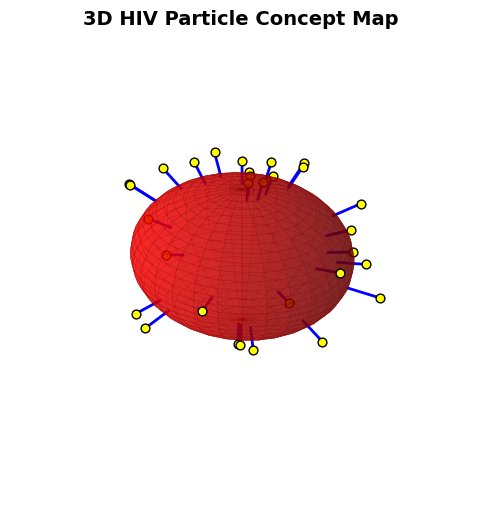

In [26]:
# --- AUTOMATIC 3D MODELING (MATPLOTLIB FALLBACK) ---
print("\n--- Generating 3D Viral Particle Concept ---")

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. Set up the 3D plotting canvas
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# 2. Create the main viral core (A 3D Sphere mesh)
u = np.linspace(0, 2 * np.pi, 30)
v = np.linspace(0, np.pi, 30)
x = 2 * np.outer(np.cos(u), np.sin(v))
y = 2 * np.outer(np.sin(u), np.sin(v))
z = 2 * np.outer(np.ones(np.size(u)), np.cos(v))

# Plot the viral core surface
ax.plot_surface(x, y, z, color='red', alpha=0.6, edgecolor='darkred', linewidth=0.2)

# 3. Add Glycoprotein Spikes protruding from the core
np.random.seed(42)
for _ in range(30):
    theta = np.random.uniform(0, np.pi)
    phi = np.random.uniform(0, 2 * np.pi)
    
    x_base = 2 * np.sin(theta) * np.cos(phi)
    y_base = 2 * np.sin(theta) * np.sin(phi)
    z_base = 2 * np.cos(theta)
    
    x_tip = 2.6 * np.sin(theta) * np.cos(phi)
    y_tip = 2.6 * np.sin(theta) * np.sin(phi)
    z_tip = 2.6 * np.cos(theta)
    
    ax.plot([x_base, x_tip], [y_base, y_tip], [z_base, z_tip], color='blue', linewidth=2)
    ax.scatter(x_tip, y_tip, z_tip, color='yellow', s=40, edgecolor='black')

ax.set_title("3D HIV Particle Concept Map", fontsize=14, fontweight='bold')
ax.axis('off')
plt.show()

## Automated Reporting
Generates a plain-text (.txt) and HTML summary report from the analysis, meant to be handed to a healthcare administrator or opened directly in a browser.


In [27]:
# --- CREATING ANALYSIS REPORTS (TXT, HTML) ---
print("\n--- Generating Automated Reports ---")

# Mock data summary for the report
total_patients = 100
avg_adherence = "82%"
high_risk_flagged = 14

# 1. Generate a Plain Text (.txt) Report
txt_filename = "monthly_hiv_summary.txt"
with open(txt_filename, "w") as f:
    f.write("MONTHLY EPIDEMIOLOGICAL SUMMARY\n")
    f.write("===============================\n")
    f.write(f"Total Patients Tracked: {total_patients}\n")
    f.write(f"Average ARV Adherence: {avg_adherence}\n")
    f.write(f"High-Risk Patients Flagged by AI: {high_risk_flagged}\n")
    f.write("\nRecommendation: Deploy mobile clinic to North District.")

print(f"Text report successfully saved as: {txt_filename}")

# 2. Generate an HTML Report (Can be opened in Chrome/Edge/Safari)
html_filename = "monthly_hiv_summary.html"
html_content = f"""
<html>
<head>
    <title>HIV Platform Report</title>
    <style>
        body {{ font-family: Arial, sans-serif; margin: 40px; }}
        h1 {{ color: #cc0000; }}
        .metric {{ font-size: 1.2em; font-weight: bold; }}
    </style>
</head>
<body>
    <h1>Monthly Epidemiological Summary</h1>
    <hr>
    <ul>
        <li><span class="metric">Total Patients Tracked:</span> {total_patients}</li>
        <li><span class="metric">Average ARV Adherence:</span> {avg_adherence}</li>
        <li><span class="metric">High-Risk Patients Flagged by AI:</span> {high_risk_flagged}</li>
    </ul>
    <p><b>Recommendation:</b> Deploy mobile clinic to North District.</p>
</body>
</html>
"""

with open(html_filename, "w") as f:
    f.write(html_content)

print(f"HTML report successfully saved as: {html_filename}")


--- Generating Automated Reports ---
Text report successfully saved as: monthly_hiv_summary.txt
HTML report successfully saved as: monthly_hiv_summary.html


## Interactive Dashboard — Streamlit
Writes a standalone Streamlit app (dashboard.py) that visualizes patient demographics and adherence rates, and exposes basic platform controls.


In [28]:
%%writefile dashboard.py
# --- INTERACTIVE DASHBOARDS (STREAMLIT) ---
import streamlit as st
import pandas as pd
import numpy as np

# Set up the page
st.set_page_config(page_title="HIV Care Dashboard", layout="wide")
st.title("🏥 Comprehensive HIV Care & Analytics Platform")
st.markdown("Monitor patient adherence, view regional demographics, and track resource allocation.")

# Create mock data
df = pd.DataFrame({
    'Age Group': ['15-24', '25-34', '35-44', '45-54', '55+'],
    'Active Patients': [120, 350, 280, 190, 90],
    'Adherence Rate (%)': [75, 88, 92, 94, 96]
})

# Create dashboard columns
col1, col2 = st.columns(2)

with col1:
    st.subheader("Patient Demographics")
    st.bar_chart(df.set_index('Age Group')['Active Patients'])

with col2:
    st.subheader("Average ARV Adherence by Age")
    st.line_chart(df.set_index('Age Group')['Adherence Rate (%)'])

st.sidebar.header("Platform Controls")
st.sidebar.button("Run AI Risk Assessment")
st.sidebar.button("Optimize Clinic Routes")
st.sidebar.success("System Status: Online")

Overwriting dashboard.py


## Environment Setup — Backend Service
Installs Flask alongside requests, needed to run the backend microservice and send data to it.


In [30]:
# Install required libraries for Phase 5
#!pip install flask requests

import threading
import requests
from flask import Flask, request, jsonify
import time

## Creating the Backend Microservice - Flask (Code)
Description: This cell sets up an API web server. It exposes a specific secure endpoint (/api/risk) that listens for inbound patient clinical data. When it receives data, it runs the risk calculation logic and spits back a JSON response.

In [38]:
# --- MICROSERVICES: CREATION (FLASK BACKEND) ---

# 1. Initialize the Flask application
app = Flask("HIV_Care_Microservice")

# 2. Define an API endpoint that accepts POST requests containing patient variables
@app.route('/api/risk', methods=['POST'])
def analyze_patient_risk():
    # Get the JSON data sent to the microservice
    data = request.json
    
    patient_id = data.get('Patient_ID', 'Anonymous')
    age = data.get('Age', 0)
    cd4 = data.get('CD4', 500)
    adherence = data.get('Adherence', 100)
    
    # 3. Microservice Logic: Run the analytical assessment rule
    # (In a larger app, this is where you would call your saved PyTorch or Scikit-Learn models)
    if cd4 < 350 or adherence < 80:
        risk_level = "High Risk"
        action_plan = "Flag case file for immediate nursing intervention and check smart pillbox connectivity."
    else:
        risk_level = "Low Risk / Stable"
        action_plan = "Maintain current Antiretroviral (ARV) therapy plan. Schedule routine 6-month lab work."
        
    # 4. Return the processed insights back to whoever called the API
    return jsonify({
        "status": "processed",
        "patient": patient_id,
        "calculated_risk": risk_level,
        "recommended_action": action_plan,
        "timestamp": time.strftime("%Y-%m-%d %H:%M:%S")
    })

# 5. Run the microservice inside a background thread so it doesn't freeze Jupyter Lab
def start_server():
    try:
        # Running on local port 5001. debug=False avoids threading conflicts in notebooks.
        app.run(host='127.0.0.1', port=5001, debug=False, use_reloader=False)
    except Exception as e:
        print(f"Server error or port already in use: {e}")

# Checking if the server thread is already running to prevent duplication if you rerun the cell
global_threads = [t.name for t in threading.enumerate()]
if "Flask_Microservice_Thread" not in global_threads:
    backend_thread = threading.Thread(target=start_server, name="Flask_Microservice_Thread")
    backend_thread.daemon = True # Allows thread to close automatically when kernel stops
    backend_thread.start()
    print("Core AI Microservice safely spun up in a background thread on http://127.0.0.1:5001")
    time.sleep(2) # Give the server a brief moment to initialize
else:
    print("Microservice background thread is already active and listening on port 5001.")

Microservice background thread is already active and listening on port 5001.


## Utilising the Microservice - Client Request (Code)
Description: Now i will act as the "Client" (simulating a request being sent directly from your Streamlit dashboard or an external medical diagnostic device). I will package a patient's information into a request payload, send it to our local background microservice, and display the response.

In [39]:
# --- MICROSERVICES: UTILISATION (CLIENT REQUEST) ---
print("--- Communicating with Backend Microservice ---")

# 1. Define the microservice address
microservice_url = "http://127.0.0.1:5001/api/risk"

# 2. Package data for a specific high-risk patient (Age > 15)
patient_payload = {
    "Patient_ID": "PATIENT-19B",
    "Age": 21,
    "CD4": 290,         # Low CD4 Count
    "Adherence": 75     # Poor adherence
}

print(f"Sending clinical data for {patient_payload['Patient_ID']} to the API microservice...")

try:
    # 3. Send the HTTP POST request with the data payload
    api_response = requests.post(microservice_url, json=patient_payload)
    
    # 4. Parse and display the microservice's output
    if api_response.status_code == 200:
        result_data = api_response.json()
        print("\n[Microservice Response Received successfully]:")
        print(f"• Target ID:          {result_data['patient']}")
        print(f"• Diagnostic Verdict: {result_data['calculated_risk']}")
        print(f"• Action Mandate:     {result_data['recommended_action']}")
        print(f"• Server Timestamp:   {result_data['timestamp']}")
    else:
        print(f"Failed to fetch an evaluation. Server returned status code: {api_response.status_code}")
        
except Exception as e:
    print(f"Could not reach the microservice. Error details: {e}")
    print("Ensure Cell 23 executed cleanly and port 5001 is completely unblocked.")

--- Communicating with Backend Microservice ---
Sending clinical data for PATIENT-19B to the API microservice...

[Microservice Response Received successfully]:
• Target ID:          PATIENT-19B
• Diagnostic Verdict: High Risk
• Action Mandate:     Flag case file for immediate nursing intervention and check smart pillbox connectivity.
• Server Timestamp:   2026-06-06 18:00:25
